#  IMF Analysis
This analysis begins with analyzing raw data from laser power scans to get counts/s/mW and calculates the solid angle, laser power distribution, and atoms per bin to get a preliminary value for the fluorescence cross section.

In [14]:
#imports:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np 
#import read_spe as spe #need the specific read_spe file in the same folder (shouldn't be an issue on SpinLab computers) 
import glob
import os
import numba
from scipy import integrate
import scipy.special as ss
import sympy as sp
from math import erf
import math

In [16]:
test = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2026-02-16\LPS 721 nm\0.1 mW\Test_LPS_721_nm_0.1_mW_2026-02-16-163003.txt")

In [17]:
print(test)

    Loop Start Time (s)\tFrequency (THz)\tPower (V)\tCCD Frame Start Time (s)\tCCD Total Counts
0    25.186858654022\t415.800870950396\t0.015171398...                                         
1    29.174384117126\t415.800871895263\t0.014957586...                                         
2    30.316607952118\t415.800868104013\t0.015171398...                                         
3    31.468734264374\t415.800865816689\t0.015005282...                                         
4    32.617222309113\t415.800870846782\t0.014493778...                                         
5    33.784470558167\t415.800869063063\t0.013817802...                                         
6    34.928422451019\t415.800868455251\t0.013651687...                                         
7    36.085599899292\t415.800868837758\t0.013697739...                                         
8    37.238937854767\t415.800866642695\t0.013654976...                                         
9    38.389905452728\t415.800868334439\t

# Reading in / Sorting Text Files

### Bias 

In [65]:
# read in bias data (no film)
bias = pd.read_csv(
    r"I:\projects\spinlab_data\IMF Data\2026-03-09 Bias Scans\Bias_2026-03-09-145811.txt"
    , sep="\t")
bias_settings = pd.read_csv(
    r"I:\projects\spinlab_data\IMF Data\2026-03-09 Bias Scans\Bias_2026-03-09-145811_SETTINGS.txt"
                            , header=None, sep=":")

#### if using Erin's folder setup (all power for each wavelength in one folder) using the following 2 cells to read in files

In [4]:
# p = r"D:\Karina Data 2.16.26\Empty"
# undoped_nm_dict = {}
# undoped_nm_settings_dict = {}
# for root, dirs, files in os.walk(p):
#     wavelength = os.path.basename(root)
#     power_dict = {}
#     power_dict_settings = {}
#     for file in files:
#         fp = os.path.join(root, file)
#         if ".txt" in file:      
#             if "SETTINGS" in os.path.basename(fp):
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#             else:
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict[power] = pd.read_csv(fp, sep="\t")
#         else:
#             continue  
#     undoped_nm_dict[wavelength] = power_dict
#     undoped_nm_settings_dict[wavelength] = power_dict_settings

In [7]:
# p = r"D:\Karina Data 2.16.26\Doped"
# doped_nm_dict = {}
# doped_nm_settings_dict = {}
#     for root, dirs, files in os.walk(p):
#         wavelength = os.path.basename(root)
#         power_dict = {}
#         power_dict_settings = {}
#         for file in files:
#             fp = os.path.join(root, file)
#             if ".txt" in file:      
#                 if "SETTINGS" in os.path.basename(fp):
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power=  power.split("mW")[0]
#                     power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#                 else:
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power = power.split("mW")[0]
#                     power_dict[power] = pd.read_csv(fp, sep="\t")
#             else:
#                 continue
#     doped_nm_dict[wavelength] = power_dict
#     doped_nm_settings_dict[wavelength] = power_dict_settings

#### if using Karina's file setup (folder for each power inside each wavelength folder) use following 2 cells to read in files)

In [40]:
undoped_path = r"I:/projects/spinlab_data/IMF Data/2026-02-25"
#set up dictionaries
undoped_nm_dict = {}
undoped_nm_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(undoped_path):
    wavelength_path = os.path.join(undoped_path, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    if '.ipynb' in wavelength:
        continue
    if '.PNG' in wavelength:
        continue
    print(wavelength)
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        if not os.path.isdir(power_path):
            continue

        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:  
                #read in as settings file
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    #read in as power file
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue

    undoped_nm_dict[wavelength] = power_dict
    undoped_nm_settings_dict[wavelength] = power_settings_dict

711
721
730
743
757


In [42]:
#repeat for doped
doped_path = r"I:\projects\spinlab_data\IMF Data\2026-04-21\4K LPS"
doped_nm_dict = {}
doped_nm_settings_dict = {}
for wavelength_folder in os.listdir(doped_path):
    wavelength_path = os.path.join(doped_path, wavelength_folder)
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    if '.ipynb' in wavelength:
        continue
    if '.PNG' in wavelength:
        continue
    print(wavelength)
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        if not os.path.isdir(power_path):
            continue
        power = power.replace(" mW","")
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue
    doped_nm_dict[wavelength] = power_dict
    doped_nm_settings_dict[wavelength] = power_settings_dict

715
744


In [43]:
print(undoped_nm_dict['757'].keys())

dict_keys(['0', '0.1', '0.3', '1', '3', '5'])


In [44]:
#needs to be same length as doped - if this is not an issue, comment out this cell
del undoped_nm_dict['721']['5']

In [45]:
#sorting to make sure powers are in order
undoped_nm_dict = {k: v for k, v in sorted(undoped_nm_dict.items(), key=lambda item: item[0])}
undoped_nm_settings_dict = {k: v for k, v in sorted(undoped_nm_settings_dict.items(), key=lambda item: item[0])}
doped_nm_dict = {k: v for k, v in sorted(doped_nm_dict.items(), key=lambda item: item[0])}
doped_nm_settings_dict = {k: v for k, v in sorted(doped_nm_settings_dict.items(), key=lambda item: item[0])}

In [46]:
#convert dictionaries to lists for easier indexing
undoped_nm = []
for wavelength in undoped_nm_dict:
    power_dict = undoped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_nm.append(power_list)

undoped_settings_nm = []
for wavelength in undoped_nm_settings_dict:
    power_dict = undoped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_settings_nm.append(power_list)

doped_nm = []
for wavelength in doped_nm_dict:
    power_dict = doped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_nm.append(power_list)

doped_settings_nm = []
for wavelength in doped_nm_settings_dict:
    power_dict = doped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_settings_nm.append(power_list)


# Calculating Counts/s for all Wavelengths

### undoped

In [47]:
power_meter_range = 1.451223E-02
#this should be the same for each file: if not, the location of the value is doped_settings_nm[i][j].iloc[3,1])

In [48]:
#find average voltage for each undoped file, add them to a new list
#do the same with uncertainties
averageVoltageUndoped = []
for wavelength in undoped_nm: 
    wavelengthVoltageUndoped = []
    for power in wavelength:
        wavelengthVoltageUndoped.append(power.iloc[:,2].mean())
    averageVoltageUndoped.append(wavelengthVoltageUndoped)

In [49]:
#convert power meter range (W) to mW
pwr = power_meter_range * 1000

#Erin's code says divide it by 2, not really sure why 
#power = voltage x power range / 2
#convert from V to mW
averagePowerUndoped = []
uncertaintyPowerUndoped = []

for i in range(len(undoped_nm)):
    wavelengthPowerUndoped = []
    wavelengthPowerUncertaintyUndoped = []
    for j in range(len(undoped_nm[i])):
        wavelengthPowerUndoped.append(averageVoltageUndoped[i][j] * pwr/2)
        wavelengthPowerUncertaintyUndoped.append((undoped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(103))
    averagePowerUndoped.append(wavelengthPowerUndoped)
    uncertaintyPowerUndoped.append(wavelengthPowerUncertaintyUndoped)

In [50]:
#find average counts per frame
averageCountsUndoped = []
uncertaintyCountsUndoped = []
cpsUndoped = []
uncertaintyCpsUndoped = []

for i in range(len(undoped_nm)):
    wavelengthCountsUndoped = []
    wavelengthCountsUndopedUncertainty = []
    for j in range(len(undoped_nm[i])):
        wavelengthCountsUndoped.append((undoped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsUndopedUncertainty.append((undoped_nm[i][j].iloc[:,4].std()))
    averageCountsUndoped.append(wavelengthCountsUndoped)
    uncertaintyCountsUndoped.append(wavelengthCountsUndopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)

for i in range(len(undoped_nm)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(undoped_nm[i])):
        wavelengthCps.append(averageCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])
        wavelengthUncertaintyCps.append((uncertaintyCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])/np.sqrt(len(undoped_nm[i][j])))
    cpsUndoped.append(wavelengthCps)
    uncertaintyCpsUndoped.append(wavelengthUncertaintyCps)

### doped

In [51]:
#find average voltage for each doped file, add them to a new list
#do the same with uncertainties
averageVoltageDoped = []

for wavelength in doped_nm: 
    wavelengthVoltageDoped = []
    for power in wavelength:
        wavelengthVoltageDoped.append(power.iloc[:,2].mean())
    averageVoltageDoped.append(wavelengthVoltageDoped)

In [52]:
#convert power meter range (W) to mW
#convert from V to mW
averagePowerDoped = []
uncertaintyPowerDoped = []

for i in range(len(doped_nm)):
    wavelengthPowerDoped = []
    wavelengthPowerUncertaintyDoped = []
    for j in range(len(doped_nm[i])):
        wavelengthPowerDoped.append(averageVoltageDoped[i][j] * (pwr/2))
        wavelengthPowerUncertaintyDoped.append((doped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(len(doped_nm[i][j])))
    averagePowerDoped.append(wavelengthPowerDoped)
    uncertaintyPowerDoped.append(wavelengthPowerUncertaintyDoped)

In [53]:
#double checking exposure time
float(doped_settings_nm[0][0].iloc[1,1])

1e-05

In [69]:
#find average counts per frame
averageCountsDoped = []
uncertaintyCountsDoped = []
cpsDoped = []
uncertaintyCpsDoped = []

for i in range(len(doped_nm)):
    wavelengthCountsDoped = []
    wavelengthCountsDopedUncertainty = []
    for j in range(len(doped_nm[i])):
        wavelengthCountsDoped.append((doped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsDopedUncertainty.append((doped_nm[i][j].iloc[:,4].std()))
    averageCountsDoped.append(wavelengthCountsDoped)
    uncertaintyCountsDoped.append(wavelengthCountsDopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)

for i in range(len(averageCountsDoped)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(averageCountsDoped[i])):
        wavelengthCps.append(averageCountsDoped[i][j]/float(doped_settings_nm[0][0].iloc[1,1]))
        wavelengthUncertaintyCps.append((uncertaintyCountsDoped[i][j]/float(doped_settings_nm[0][0].iloc[1,1]))/np.sqrt(len(doped_nm[i][j])))
    cpsDoped.append(wavelengthCps)
    uncertaintyCpsDoped.append(wavelengthUncertaintyCps)

In [70]:
print(doped_settings_nm[0][0].iloc[1,1])

1e-05


In [71]:
#find average counts
bias_avg_counts = bias.iloc[:,4].mean()
#find counts per second
bias_cps = bias_avg_counts / (float(doped_settings_nm[0][0].iloc[1,1]))
#uncertainty
bias_uncertainty = np.std(bias.iloc[:,4]) / np.sqrt(len(bias))

In [72]:
print(bias_cps)

62972383515054.83


In [75]:
#subtract bias from doped and undoped datas
cpsDopedNoBias = np.zeros_like(cpsDoped)
for i in cpsDoped:
    cpsDopedNoBias[i] = cpsDoped[i] - bias_cps
cpsUndopedNoBias = np.zeros_like(cpsUndoped)
for i in cpsUndoped:
    cpsUndopedNoBias[i] = cpsUndoped[i] - bias_cps

TypeError: list indices must be integers or slices, not list

In [76]:
#converting everything into arrays
cpsUndopedArray = []
cpsUndopedNBArray = []
cpsDopedArray = []
cpsDopedNBArray = []
for i in range(len(cpsUndoped)):
    cpsUndopedArray.append(np.array(cpsUndoped[i]))
    #cpsUndopedNBArray.append(np.array(cpsUndopedNoBias[i]))
for i in range(len(cpsDoped)):
    cpsDopedArray.append(np.array(cpsDoped[i]))
   # cpsDopedNBArray.append(np.array(cpsDopedNoBias[i]))

In [77]:
#looking at effects of removing bias
plt.figure(figsize=(10,4))
plt.suptitle("Effects of Subtracting Bias on Doped and Undoped Krypton Films (@ 730nm)")
plt.subplot(1,2,1)
plt.title("Undoped Film")
plt.ylabel("Counts/s")
plt.xlabel("Power (mW)")
trend = np.polyfit(averagePowerUndoped[2], cpsUndoped[2], 1)
plot = np.poly1d(trend)
trend2 = np.polyfit(averagePowerUndoped[2], cpsUndopedNBArray[2], 1)
plot2 = np.poly1d(trend2)
plt.scatter(averagePowerUndoped[2], cpsUndoped[2])
plt.scatter(averagePowerUndoped[2], cpsUndopedNBArray[2])
plt.plot(averagePowerUndoped[2], plot(averagePowerUndoped[2]), label='With Bias')
plt.plot(averagePowerUndoped[2], plot2(averagePowerUndoped[2]), label='Minus Bias')

plt.subplot(1,2,2)
plt.title("Doped Film")
plt.ylabel("Counts/s")
plt.xlabel("Power (mW)")
trend = np.polyfit(averagePowerDoped[2], cpsDoped[2], 1)
plot = np.poly1d(trend)
trend2 = np.polyfit(averagePowerDoped[2], cpsDopedNBArray[2], 1)
plot2 = np.poly1d(trend2)
plt.scatter(averagePowerDoped[2], cpsDoped[2])
plt.scatter(averagePowerDoped[2], cpsDopedNBArray[2])
plt.plot(averagePowerDoped[2], plot(averagePowerDoped[2]), label='With Bias')
plt.plot(averagePowerDoped[2], plot2(averagePowerDoped[2]), label='Minus Bias')
plt.legend()
plt.tight_layout()

IndexError: list index out of range

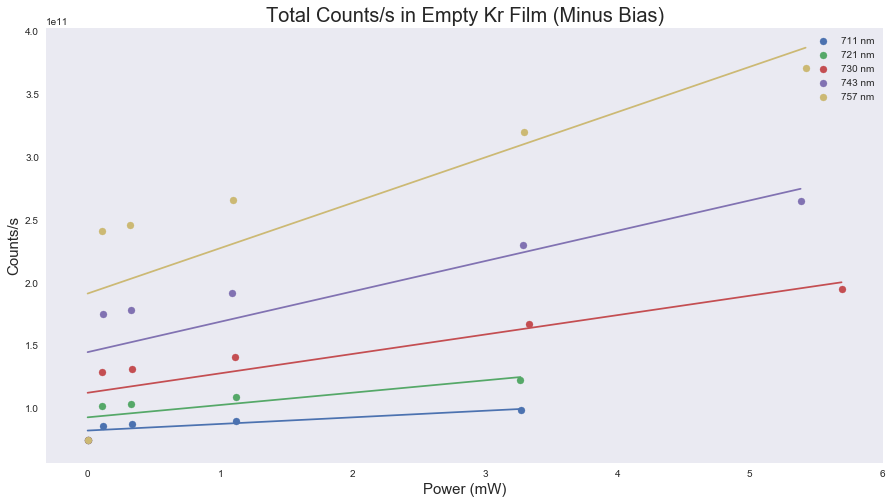

In [81]:
plt.figure(figsize=(15,8))
for i in range(len(cpsUndoped)):
    trend = np.polyfit(averagePowerUndoped[i], cpsUndopedArray[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cpsUndopedArray[i], label=list(undoped_nm_dict)[i]+" nm")
plt.legend()
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Empty Kr Film (Minus Bias)", fontsize=20)
plt.show()

[  3.84611236e+13   9.15466466e+13]
[  9.92550966e+13   1.80711915e+14]


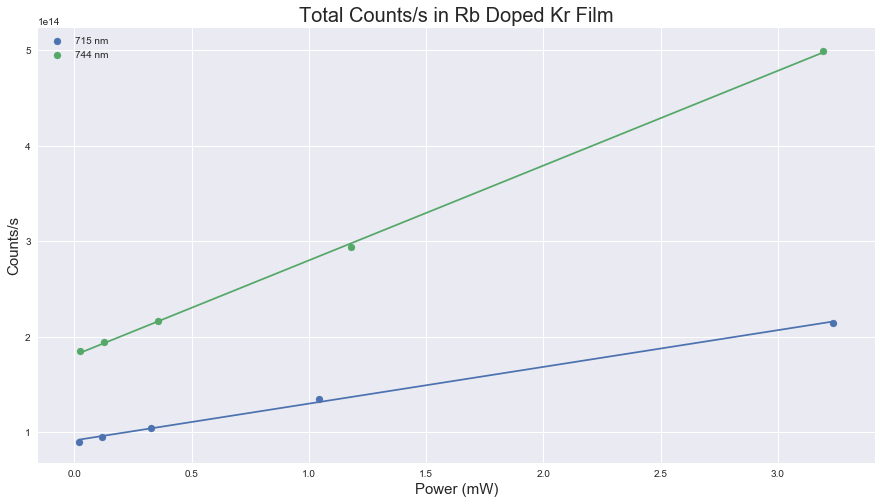

In [86]:
plt.figure(figsize=(15,8))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDopedArray[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cpsDopedArray[i], label=list(doped_nm_dict)[i]+" nm")
    print(trend)
plt.legend()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Rb Doped Kr Film", fontsize=20)
plt.show()

Text(0, 0.5, 'Counts/s')

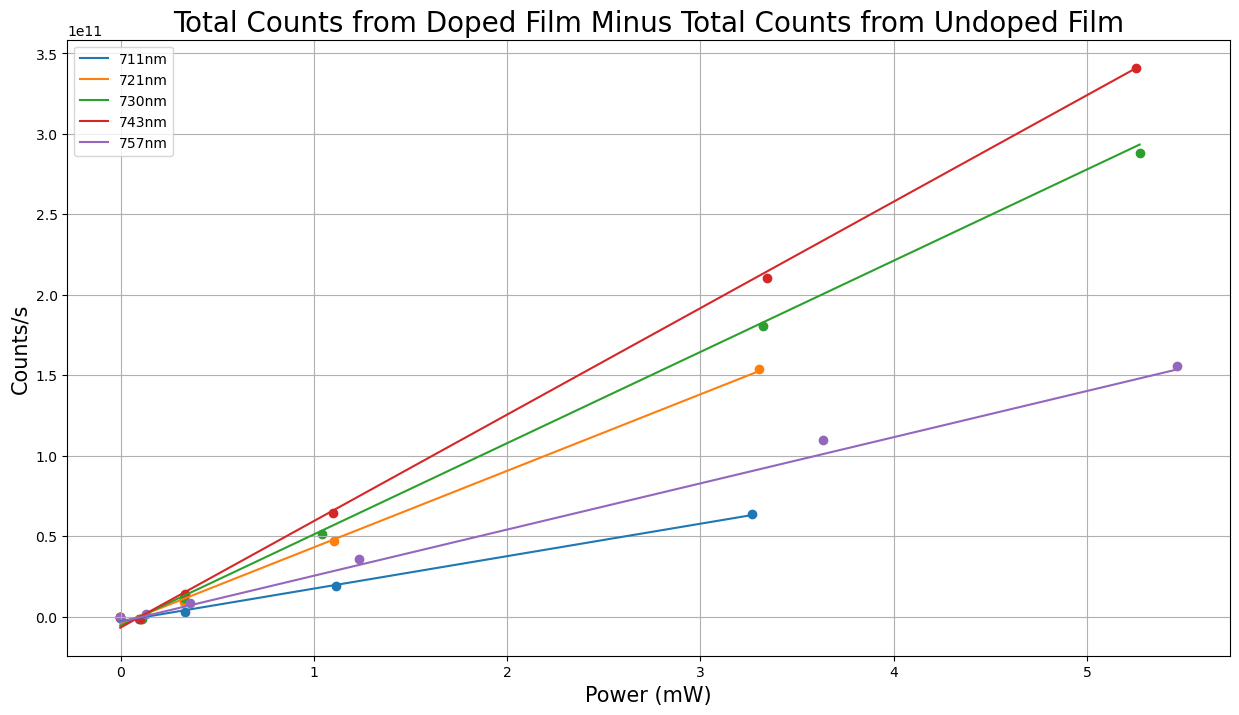

In [34]:
plt.figure(figsize=(15,8))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDoped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cpsUndoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_nm_dict)[i] + "nm")
    plt.scatter(averagePowerDoped[i], np.array(cpsDoped[i]) - np.array(cpsUndoped[i]))
plt.legend()
plt.grid()
plt.title("Total Counts from Doped Film Minus Total Counts from Undoped Film", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)

# Reading in / cleaning SPE files

In [36]:
#set region of interest (ROI)
#I'm using Erin's 
roi_x1 = 390
roi_x2 = 700
roi_y1 = 450
roi_y2 = 700
#roi sizes
roi_x = roi_x2 - roi_x1
roi_y = roi_y2 - roi_y1
#also define total area
x_size = 1024
y_size = 1024

In [37]:
%%time
p = undoped_path
#set up dictionaries
undoped_spe_dict = {}
undoped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    print(wavelength)
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        if not os.path.isdir(power_path):
            continue
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                spo = spe.SpeReference(fp)
                test2 = spe.SpeReference.get_data(spo)[0].astype(np.float32)
                power_dict[power] = test2
            else:
                continue

    undoped_spe_dict[wavelength] = power_dict
    undoped_spe_settings_dict[wavelength] = power_settings_dict

730
743
757
711
721
CPU times: total: 42.3 s
Wall time: 1min 14s


In [38]:
%%time
p = doped_path
#set up dictionaries
doped_spe_dict = {}
doped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    print(wavelength)
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        if not os.path.isdir(power_path):
            continue
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                spo = spe.SpeReference(fp)
                test2 = spe.SpeReference.get_data(spo)[0].astype(np.float32)
                power_dict[power] = test2
            else:
                continue
    doped_spe_dict[wavelength] = power_dict


721
730
743
757
711
CPU times: total: 37.3 s
Wall time: 1min 6s


In [39]:
print(list(doped_spe_dict.keys()))
print(list(undoped_spe_dict.keys()))

['721', '730', '743', '757', '711']
['730', '743', '757', '711', '721']


In [40]:
#sort by wavelength
undoped_spe_dict = {k: v for k, v in sorted(undoped_spe_dict.items(), key=lambda item: item[0])}
doped_spe_dict = {k: v for k, v in sorted(doped_spe_dict.items(), key=lambda item: item[0])}

In [41]:
print(undoped_settings_nm[0][0].iloc[1,1])

0.01


In [42]:
print(list(undoped_nm_dict.keys()))
print(list(undoped_spe_dict.keys()))

['711', '721', '730', '743', '757']
['711', '721', '730', '743', '757']


In [43]:
#convert to lists
undoped_spe = []
for wavelength in undoped_spe_dict:
    power_dict = undoped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_spe.append(power_list)
doped_spe = []
for wavelength in doped_spe_dict:
    power_dict = doped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_spe.append(power_list)

In [44]:
#get roi lists
undoped_spe_roi = []
for wavelength in undoped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_spe_roi.append(roi)
doped_spe_roi = []
for wavelength in doped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_spe_roi.append(roi)

In [45]:
print(np.shape(undoped_spe_roi[0][0]))

(103, 251, 311)


### Average Counts Analysis

In [47]:
#find total counts for whole frame
undoped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe]
doped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe]

In [48]:
#find total counts for roi
undoped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe_roi]
doped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe_roi]

In [49]:
#checking to make sure all are same length
for i in range(len(averagePowerDoped)):
    print(len(averagePowerDoped[i]), len(averagePowerUndoped[i]))

5 5
5 5
6 6
6 6
6 6


In [50]:
#double checking exposure time
float(doped_settings_nm[0][0].iloc[1,1])

0.01

In [51]:
#find counts per second for roi
cps_undoped = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in undoped_avgs]
cps_doped = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in doped_avgs]

In [52]:
%%time
#find counts per second for full frame
cps_total_u = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in undoped_total]
cps_total_d = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in doped_total]

CPU times: total: 15.6 ms
Wall time: 6 ms


In [56]:
#fix this
cps_undoped[1] = cps_undoped[1][:5]
cps_doped = cps_doped[:5]

In [58]:
#more lengths checks
for i in range(len(cps_undoped)):
    print(len(cps_total_u[i]), len(averagePowerUndoped[i]))

5 5
6 5
6 6
6 6
6 6


Text(0.5, 1.0, 'ROI counts in undoped Kr film')

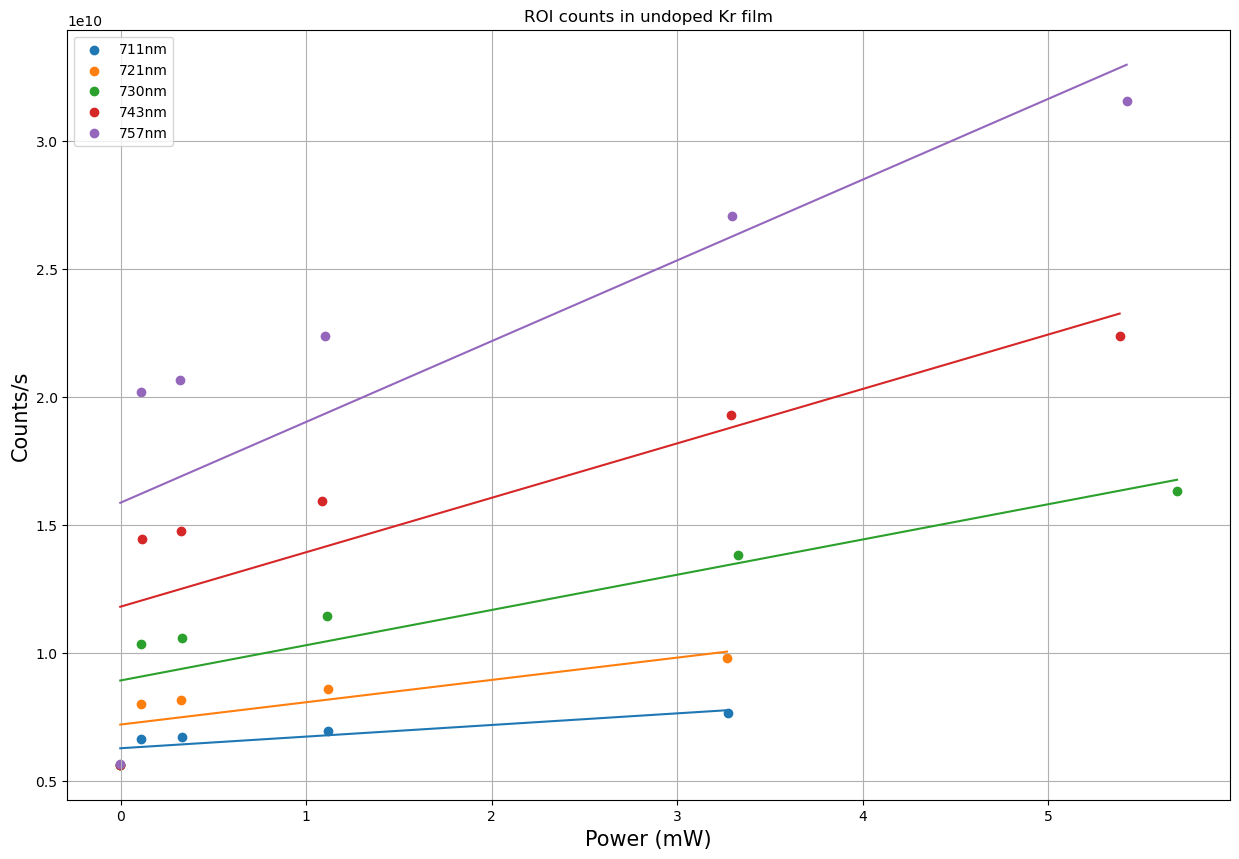

In [60]:
plt.figure(figsize=(15,10))
for i in range(len(cps_undoped)):
    trend = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cps_undoped[i], label=list(undoped_spe_dict)[i]+"nm")
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.legend()
plt.title("ROI counts in undoped Kr film")

Text(0.5, 1.0, 'ROI Counts in Rb Doped Krypton Film')

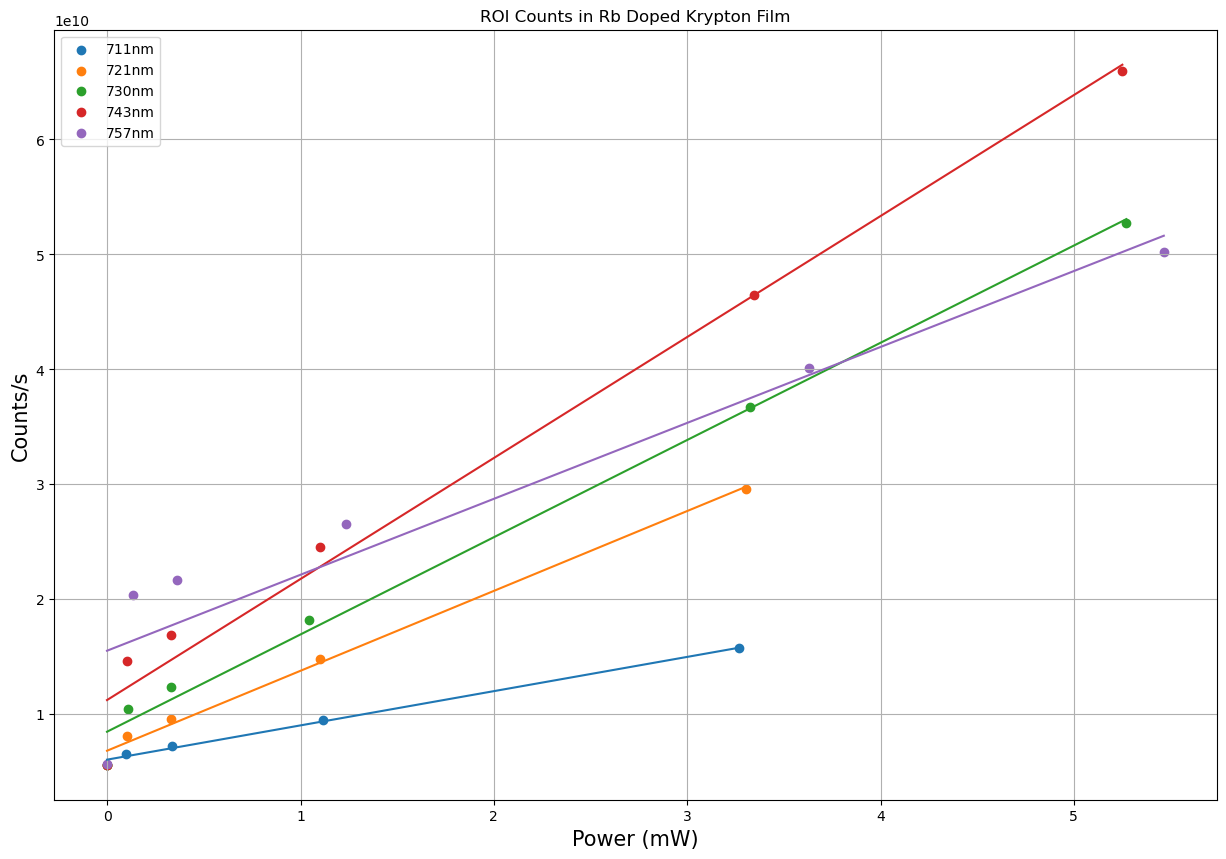

In [62]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cps_doped[i], label=list(doped_spe_dict)[i]+"nm")
plt.grid()
plt.legend()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("ROI Counts in Rb Doped Krypton Film")

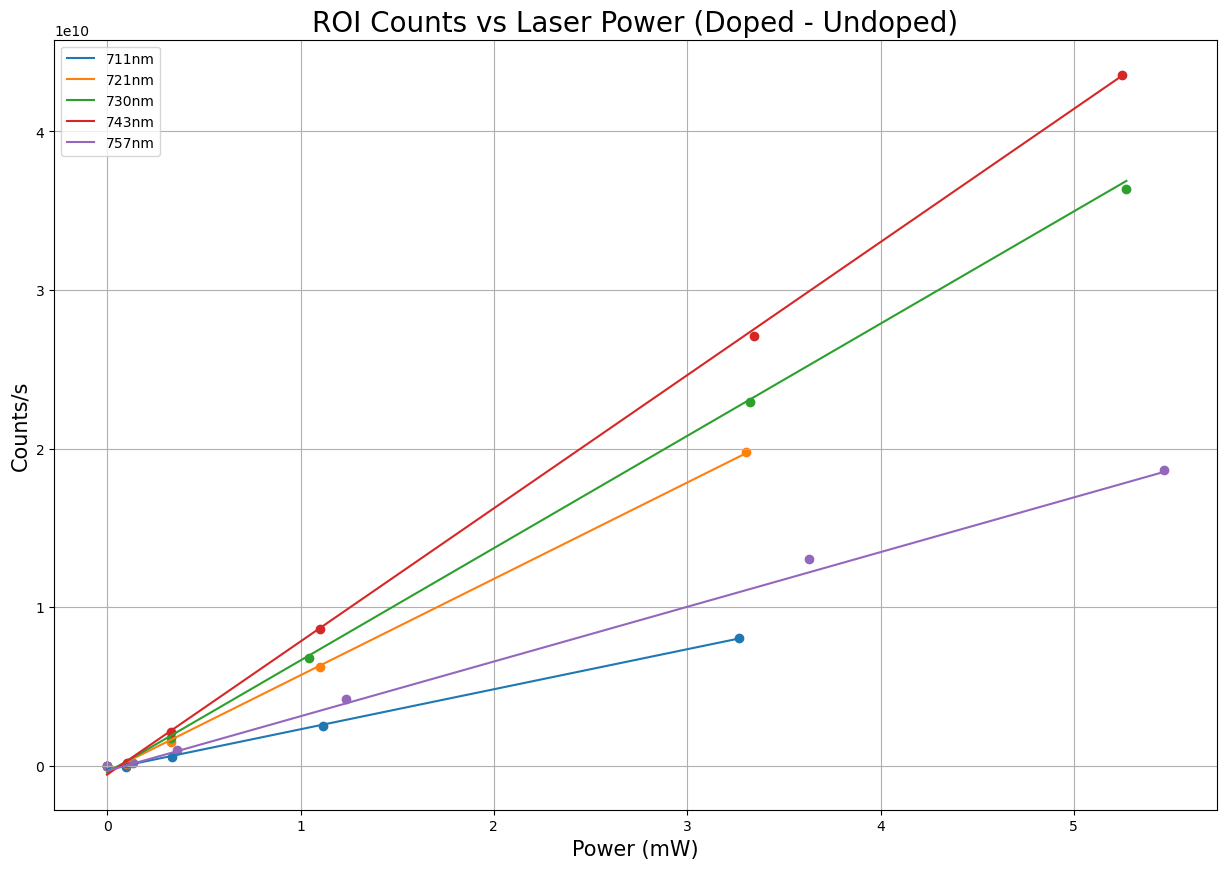

In [63]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_spe_dict)[i]+"nm")
    plt.scatter(averagePowerDoped[i], np.array(cps_doped[i]) - np.array(cps_undoped[i]))
plt.legend()
plt.title("ROI Counts vs Laser Power (Doped - Undoped)", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.grid()

## Per Pixel Analysis

In [65]:
#set parameters
substrate_width = 2.54 #cm
exp_t = float(doped_settings_nm[0][0].iloc[1,1])

In [66]:
#define important stuff
pixel_area = (substrate_width / x_size)**2 #cm^2
pixel_width = substrate_width / x_size

In [67]:
#find average counts over frames for each pixel in the ROI
cpp_undoped = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in undoped_spe_roi]
cpp_doped = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in doped_spe_roi]

In [68]:
%%time
#find average counts for each pixel in the full frame
#this cell takes forever
cpp_undoped_tot = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in undoped_spe]
cpp_doped_tot = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in doped_spe]

CPU times: total: 1min 28s
Wall time: 3min 44s


## Solid Angle Calculation

In [560]:
#sa constants
r_lens = 5.08/2
pixels = 1024
z_lens = 41.78
pixel_width = substrate_width / pixels
r_film = substrate_width/2 

lens_area = np.pi*(r_lens**2)
sphere = 4*np.pi*(z_lens**2)
sa_whole = lens_area / sphere
#checking a simplified version 
print(sa_whole)

0.0009239970201110421


In [562]:
#define spherical lens and get one set of values from each ring

# output is array with dimensions (Npts*Npts,3)
# where first index is the point number which is composed of a 3D location vector
# origin is the top of curved surface and if Rc>0, then the rest of the points are below the xy-plane
# the normal vector for the tip of the spherical cap is z-hat
def get_surface_spherical_cap_3D(Npts,Rc,dia):
    nvecs = np.zeros((Npts*Npts,3))
    locs = np.zeros((Npts*Npts,3))
    nvec =[]
    loc = []
    R = dia/2.0
    z = np.sqrt(Rc**2-R**2)
    count = 0
    for k in np.arange(Npts):
        rk = R*(3.0*k*k+3.0*k+1.0)/3.0/Npts/np.pi
        randphi = np.random.uniform(0.0,2.0*np.pi)
        for l in np.arange(2*k+1):
            
            phil = 2.0*np.pi*l/(2.0*k+1.0)+randphi
            xkl = +rk*(np.sin(phil+2.0*np.pi/(2.0*k+1.0))-np.sin(phil))
            ykl = -rk*(np.cos(phil+2.0*np.pi/(2.0*k+1.0))-np.cos(phil))
            phi = np.arctan2(ykl,xkl)
            theta = np.arctan(np.sqrt(xkl**2+ykl**2)/z)
            nvecs[count] = np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
            locs[count] = np.array([Rc*np.sin(theta)*np.cos(phi),Rc*np.sin(theta)*np.sin(phi),Rc*np.cos(theta)-Rc])
            #addition to take only 1 value per 'ring'
            #if there's already a value in here for that pixel, then move to the next
            if len(nvec) > k: 
                continue
            #if not, append the information from this function to our output
            else:
                nvec.append(nvecs[count])
                loc.append(locs[count])
            count = count+1
    return locs , nvecs, loc, nvec

In [564]:
%%time
#run the function
lens_loc, normal, one_normal, one_loc = get_surface_spherical_cap_3D(pixels, z_lens, r_lens*2)

CPU times: total: 52.9 s
Wall time: 58.9 s


In [258]:
#set up bin size function that takes in a ring number (from the previous function) and returns the area of them
def bin_size(ring_number):
    inner_ring = np.pi * (ring_number)**2 * pixel_width**2
    outer_ring = np.pi * (ring_number+1)**2 * pixel_width**2
    area = outer_ring - inner_ring
    return area

In [261]:
one_loc = np.array(one_loc)
one_normal = np.array(one_normal)

In [566]:
lens_bin = []
#for each ring, calculate its size
for i in range(len(one_loc)):
    lens_bin.append(bin_size(i))

In [568]:
lens_bin = np.array(lens_bin)

In [267]:
%%time
#solid angle factor function
@numba.njit(parallel=True)
def safactor(pieces):
    sa = np.zeros((pixels, pixels))
    lens = np.zeros((pieces, pieces))
    for x in numba.prange(len(sa[0])):
        for y in numba.prange(len(sa[1])):
    
            x_dist = (x - (.5*pixels)) * pixel_width
            y_dist = (y - (.5*pixels)) * pixel_width
            if x_dist**2 + y_dist**2 > r_film**2:
                sa[x,y] = 0
                continue
            else:
                for i in range(len(one_loc)):
                    lx, ly, lz = one_loc[i]
                    nx, ny, nz = one_normal[i]
                    bin_size = lens_bin[i]
                    lx_dist = lx
                    ly_dist = ly
                    xx = x_dist - lx_dist
                    yy = y_dist - ly_dist
                    zz = z_lens - lz 
                    displacement = np.sqrt((-lx_dist + x_dist)**2 + (-ly_dist + y_dist)**2) 
                    hyp = np.sqrt(xx**2 + yy**2 + zz**2)
                    if lx_dist**2 + ly_dist**2 > r_lens**2:
                        sa[x,y] += 0
                        continue
                    numerator = ( xx*nx + yy*ny + zz*nz)
                    denom = 4*np.pi*((hyp**3))
                    sa[x,y] += (numerator*bin_size/denom)
    return sa

CPU times: total: 15.6 ms
Wall time: 6.69 ms


In [269]:
%%time
sa = safactor(1024)

CPU times: total: 14 s
Wall time: 8.51 s


In [298]:
print(np.mean(sa_roi)

0.0007198033018190581


0.0009171269236545815


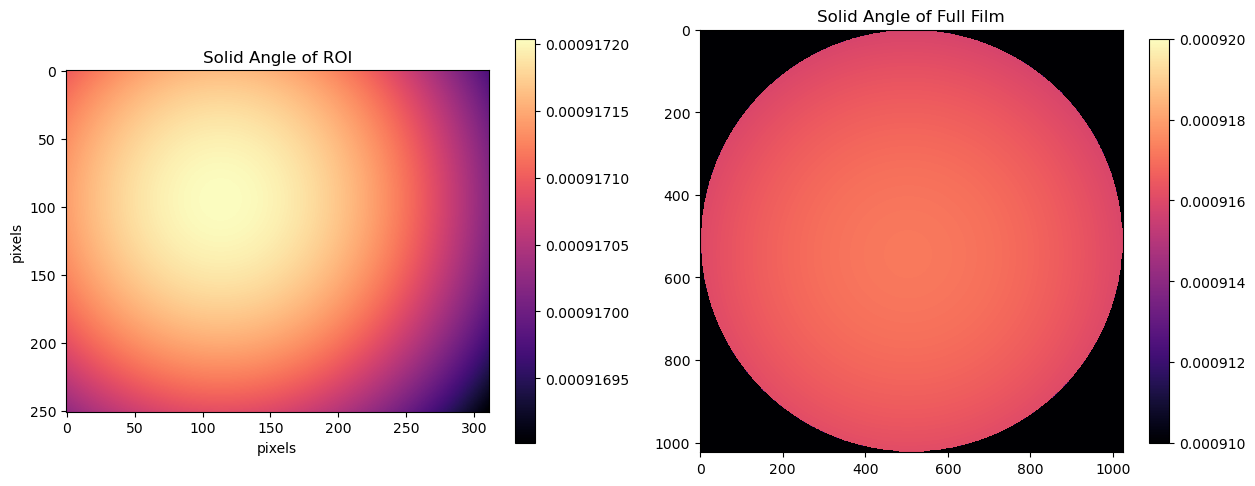

In [300]:
plt.figure(figsize=(15,15))
sa_roi = sa[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]
plt.subplot(1,2,1)
print(np.mean(sa_roi))
plt.imshow(sa_roi, 'magma')
plt.colorbar(shrink=.35)
plt.title('Solid Angle of ROI')
plt.xlabel('pixels')
plt.ylabel('pixels')
plt.subplot(1,2,2)
plt.imshow(sa,'magma')
plt.title("Solid Angle of Full Film")
plt.colorbar(shrink=.35)
plt.clim(0.00091, 0.00092)

In [302]:
#make dataframe and append into 2D form for histogram use
sa_df = []
for y in range(len(sa_roi)):  
    for x in range(len(sa_roi[0])): 
        sa_df.append({
            'x': x,
            'y': y,
            'value': sa_roi[y][x]})

In [304]:
sa_df = pd.DataFrame(sa_df)

# Laser Distribution

In [231]:
#find intensity (assuming power is evenly distributed)
#intensity in mW/cm^2
intensity_undoped = []
for wavelength in averagePowerUndoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_undoped.append(intensity)

intensity_doped = []
for wavelength in averagePowerDoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_doped.append(intensity)

In [110]:
#find the shortest data file to cut everything down to
#this is a hideously bad way to do this and I should fix it
undoped_min_len = []
for i in range(len(cpp_undoped)):
    undoped_min_len.append(len(cpp_undoped[i]))
print(min(undoped_min_len))

5


In [112]:
#cut everything down
#graphing via loops only works if everything is the same length, hence the trimming of the data
for i in range(len(cpp_undoped)):
    cpp_undoped[i] = np.array(cpp_undoped[i])[:min(undoped_min_len)]
    cpp_doped[i] = np.array(cpp_doped[i])[:min(undoped_min_len)]
    intensity_doped[i] = np.array(intensity_doped[i])[:min(undoped_min_len)]
    cpp_doped[i] = cpp_doped[i][:min(undoped_min_len)]
    intensity_undoped[i] = intensity_undoped[i][:min(undoped_min_len)]
    cpp_doped_tot[i] = cpp_doped_tot[i][:min(undoped_min_len)]
    cpp_undoped_tot[i] = cpp_undoped_tot[i][:min(undoped_min_len)]

    
    

In [113]:
#calculate slopes for each pixel (evenly distributed model)
allrows= []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(intensity_doped[i], cpp_doped[i][:,y,x], 1)
            best1, ignore = np.polyfit(intensity_undoped[i], cpp_undoped[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows.append(rows)

In [115]:
print(np.shape(cpp_undoped))

(5, 5, 251, 311)


In [570]:

sa_circle = sa
#if the value is 0, change it to nan
#this stops infinity issues in calculating the mean / stdv later on
sa_circle[sa_circle == 0] = np.nan

In [415]:
#find the fraction of counts at each pixel for the undoped frame in the full frame
fractionalCountsTotal = []
for wavelength in cpp_undoped_tot: 
    fraction = []
    for power in wavelength:
        #normalizing 
        fraction.append(power/sa_masked / np.nansum(power/sa_masked))
    fractionalCountsTotal.append(fraction)

In [416]:
for i in range(len(averagePowerUndoped)):
    print(len(averagePowerUndoped[i]),len(fractionalCountsTotal[i]))

5 5
5 5
6 5
6 5
6 5


In [417]:
#checking to ensure normalization method is correct = should be about 1 for each
for wavelength in fractionalCountsTotal:
    for power in wavelength:
        print(np.nansum(power))

0.9999999999999999
0.9999999999999997
1.0000000000000002
0.9999999999999991
1.0000000000000004
1.0000000000000007
1.0
1.0000000000000002
0.9999999999999999
0.9999999999999996
1.0000000000000002
1.0
1.0
1.0000000000000004
0.9999999999999998
0.9999999999999998
1.0000000000000007
0.9999999999999996
0.9999999999999997
0.9999999999999999
1.000000000000001
1.0000000000000002
0.9999999999999997
1.0000000000000004
1.0000000000000004


In [421]:
#find normalized power
normalized_power_undoped = []
normalized_power_doped = []
for i in range(len(fractionalCountsTotal)):
    norm = []
    norm_doped = []
    for j in range(len(fractionalCountsTotal[i])):
        #multiply the average total power by the percent of power at that pixel to get a per pixel power aka intensity
        #divide by the solid angle to remove distance's effect on the laser distribution
        norm.append(averagePowerUndoped[i][j] * fractionalCountsTotal[i][j] )
        norm_doped.append(averagePowerDoped[i][j] * fractionalCountsTotal[i][j])
    normalized_power_undoped.append(norm)
    normalized_power_doped.append(norm_doped)

In [423]:
#divide by area to get an intensity per cm^2
normalized_power_area_undoped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_undoped]
normalized_power_area_doped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_doped]

In [576]:
#checking average values
print(np.nanmean(normalized_power_area_undoped[2][1]))
print(intensity_undoped[2][1]) #mW/cm^2

0.02131584502618886
0.016739826411782035


In [426]:
#change all to arrays
for i in range(len(normalized_power_area_undoped)):
    normalized_power_area_undoped[i] = np.array(normalized_power_area_undoped[i])
    normalized_power_area_doped[i] = np.array(normalized_power_area_doped[i])
print(np.shape(normalized_power_area_undoped[0]))

(5, 1024, 1024)


In [ ]:
#these should be equal! 
print(intensity_undoped[2][1]*(x_size * y_size * pixel_area))
print(np.nansum(normalized_power_area_undoped[2][1]*pixel_area)

dict_keys(['0', '0.1', '0.3', '1', '3', '5'])
0.10799866407825298
0.10799866407825297


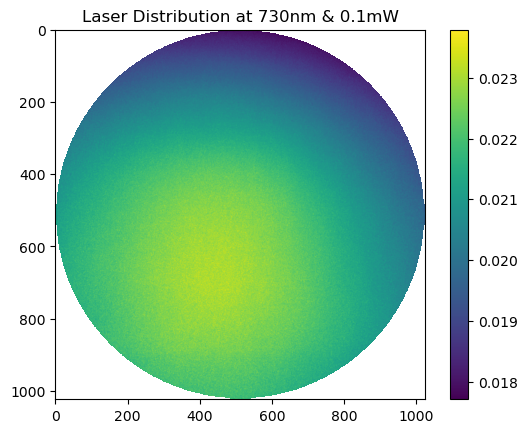

In [431]:
plt.imshow(normalized_power_area_undoped[2][1])
plt.title("Laser Distribution at 730nm & 0.1mW")
plt.colorbar()

In [433]:
#cut normalized power down to roi
undoped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_roi_pwr.append(np.array(roi))
doped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_roi_pwr.append(np.array(roi))
cpp_doped_roi = []
for wavelength in cpp_doped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_doped_roi.append(np.array(roi))
cpp_undoped_roi = []
for wavelength in cpp_undoped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_undoped_roi.append(np.array(roi))

In [435]:
#find new slopes per cm for the normalized power
allrows2 = []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(doped_roi_pwr[i][:,y,x], cpp_doped_roi[i][:,y,x], 1)
            best1, ignore = np.polyfit(undoped_roi_pwr[i][:,y,x], cpp_undoped_roi[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows2.append(rows)

In [436]:
#turning everything into arrays again
normalized_power_area_doped = np.array(normalized_power_area_doped)
normalized_power_area_undoped = np.array(normalized_power_area_undoped)
cpp_doped_tot = np.array(cpp_doped_tot)
cpp_undoped_tot = np.array(cpp_undoped_tot)

In [437]:
%%time
#find new slopes per cm for the normalized power
slopes_test = np.zeros((5,1024,1024))
for i in range(len(cpp_undoped)):
    for y in range(1024):
        for x in range(1024):
            if np.isnan(normalized_power_area_doped[i][:, y, x]).any():
                continue
            best, ignore = np.polyfit(normalized_power_area_doped[i][:,y,x], cpp_doped_tot[i][:,y,x], 1)
            best1, ignore = np.polyfit(normalized_power_area_undoped[i][:,y,x], cpp_undoped_tot[i][:,y,x], 1)
            slopes_test[i][y,x] = best-best1


CPU times: total: 19min 11s
Wall time: 20min 47s


average ROI slope of 711 nm: 158051.32798109797
STDEV difference between models for 711 nm: 0.29215006593075754
average ROI slope of 721 nm: 376512.26137699
STDEV difference between models for 721 nm: 0.3242689826485755
average ROI slope of 730 nm: 418377.4577981504
STDEV difference between models for 730 nm: 0.36305008214759366
average ROI slope of 743 nm: 496290.21012838045
STDEV difference between models for 743 nm: 0.3667567131034933
average ROI slope of 757 nm: 236443.64319519963
STDEV difference between models for 757 nm: 0.32607681706498765


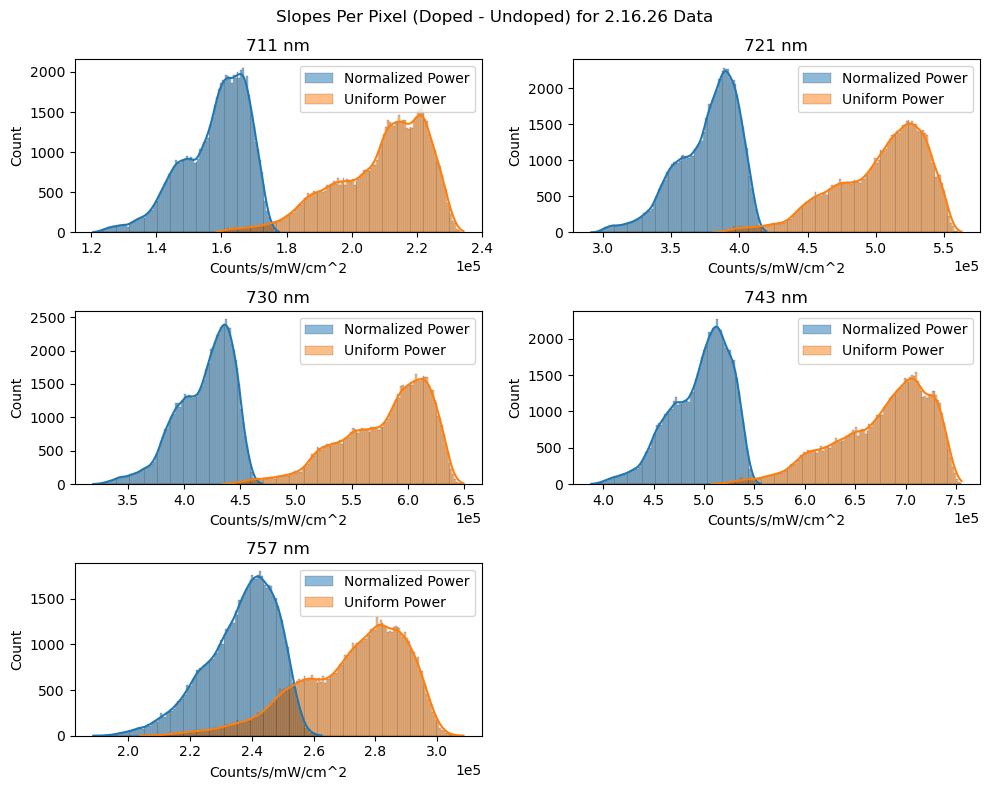

In [451]:
normalized_slopes = []
#graph comparisons
plt.figure(figsize=(10,8))
plt.suptitle("Slopes Per Pixel (Doped - Undoped) for 2.16.26 Data")
for i in range(len(allrows2)):
    x = int(i)
    plt.subplot(3,2, i+1)
    slopes_table2 = pd.DataFrame(allrows2[i])
    normalized_slopes.append(slopes_table2)
    slopes_table = pd.DataFrame(allrows[i])
    histogram = np.concatenate([slopes_table["difference"], slopes_table2["difference"]])
    bins = np.linspace(histogram.min(), histogram.max(), 200)
    sns.histplot(slopes_table2["difference"], kde=True, bins=bins,  label="Normalized Power")
    sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label="Uniform Power")
    plt.title(list(undoped_spe_dict)[i]+" nm")
    plt.ticklabel_format(axis='x', style='sci', scilimits=(5,5))
    plt.xlabel("Counts/s/mW/cm^2")
    print("average ROI slope of", list(undoped_nm_dict)[i], "nm:", slopes_table2["difference"].mean())
    print("STDEV difference between models for", list(undoped_nm_dict)[i], "nm:", 
          (slopes_table["difference"].std() - slopes_table2['difference'].std())/slopes_table['difference'].std())


    plt.legend()
plt.tight_layout()

In [459]:
#add new row to tables
slopes_table2['sa'] = slopes_table2['difference'] / sa_df['value']

In [461]:
slopes_table2['sa_whole'] = slopes_table2['difference'] / sa_whole

In [463]:
#double checking that the expected SA and the calculated SA are similar
print(np.mean(sa_df['value']))
print(sa_whole)

0.0009171269236545815
0.0009239970201110421


Percent change in standard deviation with complicated solid angle model: 0.7140659764977161 %


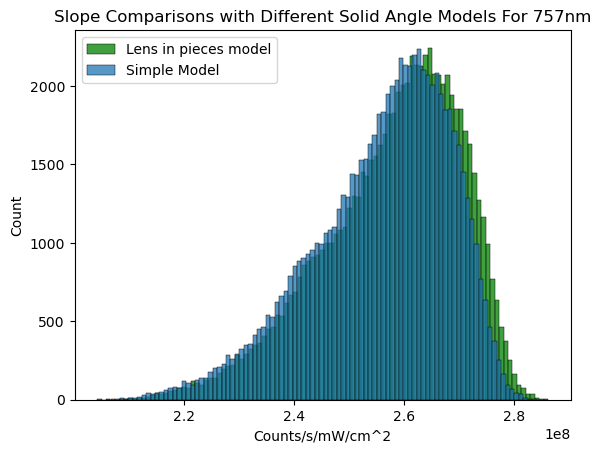

In [477]:
# histogram = np.concatenate([slopes_table2["sa_whole"], slopes_table2['sa']])
# bins = np.linspace(histogram.min(), histogram.max(), 200)
sns.histplot(slopes_table2['sa'],color='green',label='Lens in pieces model')#,bins=bins)
sns.histplot(slopes_table2['sa_whole'], label='Simple Model')#,bins=bins)
plt.title("Slope Comparisons with Different Solid Angle Models For 757nm")
plt.xlabel('Counts/s/mW/cm^2')
plt.legend()
print("Percent change in standard deviation with complicated solid angle model:",
      (np.std(slopes_table2['sa']) - np.std(slopes_table2['sa_whole']))/np.std(slopes_table2['sa_whole']) *100, "%" )

## Atomic Distribution Calculation

In [159]:
#setting up constants
#these could be function inputs but for now I'm leaving them as is
microns_hr = 5
flow_rate = 3e8
k = 2.869E-4
gamma = 1/83
#converting to same units as rest of analysis
microns_sec = microns_hr / 60 / 60 
cms_sec = microns_sec * 10e-5
growth_rate = cms_sec

In [160]:
def erf(x):
    return math.erf(x)

In [ ]:
#big ugly equation
#optimized using numba
@numba.njit
def jang_test2(theta, k, g):
    z0 = 0.5 - (1/(3*(g**2)))*((1-2*(g**3)+(2*(g**2)-1)*np.sqrt(1+(g**2)))/(np.sqrt(1+(g**2))-(g**2)*np.arcsinh(1/g)))
    z1 = 1 - z0
    d = np.sqrt((z0**2)/(2*k*(z1-z0)))    
    E = (z1/z0)*d
    j_norm = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(math.erf(E)-math.erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
    theta = np.deg2rad(theta)
    dp = np.sqrt((d**2)/np.cos(theta))
    zp = (z1/z0)*dp
    F = (2/np.sqrt(np.pi))*zp*((1/z1)-1)*(np.e**(-(zp**2)))
    p = np.tan(theta)/g       
    if theta==0:
        j0 = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(math.erf(E)-math.erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
        j = j0#/j_norm
    elif g >= np.tan((theta)): 
        #scipy.integrate does NOT work with numba so we have to manually integrate 
        #currently using midpoint rule, may switch to more complicated integration later
        R = np.arccos(p) - p*(np.sqrt(1-(p**2)))
        n = 200
        h = (p - 0)/n
        total = 0 
        for i in range(n):
            mid = 0 + (i + .5) * h
            total += np.sqrt(1-(mid**2))*(math.erf(dp*(1+((g*mid)/np.tan(theta))*((z1/z0)-1))) - math.erf(dp)) 
        j1 = z0*np.cos(theta)*(1+(2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*((R/2)*(math.erf(zp)-math.erf(dp)+F) + (total*h)) ) 
        j = j1#/j_norm
    else:
        n = 200
        h = (1 - 0)/n
        total = 0 
        for i in range(n):
            mid = 0 + (i + .5) * h
            total += np.sqrt(1-(mid**2))*(math.erf(dp*(1+((g*mid)/np.tan(theta))*((z1/z0)-1))) - math.erf(dp)) 
        j2 = z0*np.cos(theta)*(1 + (2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*total*h) 
        j = j2#/j_norm
    return j

In [195]:
%%time
jang_test2(1,k,g)

CPU times: total: 1.36 s
Wall time: 1.49 s


0.022497848068200602

In [197]:
#calculating k_norm

def k_norm(theta):
    return jang_test2(theta, k, g) * np.sin(theta)
knorm, error = integrate.quad(k_norm, 0, 1)

In [199]:
%%time
#applying k_norm and jang functions to atomic distribution
#this cell calculates expected atoms in each cm^2
atoms = np.zeros((1024,1024))
for x in range(len(atoms[0])):
    for y in range(len(atoms[1])): 
        
        x_dist = (x - (.5*pixels)) * pixel_width
        y_dist = (y - (.5*pixels)) * pixel_width
        r = np.sqrt(x_dist**2 + y_dist**2)
        theta = (np.rad2deg(np.arctan(r/z_film)) )
        atomic_dist = (flow_rate / growth_rate) * 60 * 60 * jang_test2(theta, k, g)* pixel_width**3 / ( ( z_film**2) * np.pi * knorm)
        atoms[x,y] = atomic_dist
        if r > r_film:
            atoms[x,y] = 0
            continue
        if r == 0:
            print("OKKK")

OKKK
CPU times: total: 1min 2s
Wall time: 1min 7s


In [201]:
atoms_roi = atoms[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]

Text(0.5, 1.0, '# of Rb Atoms in ROI')

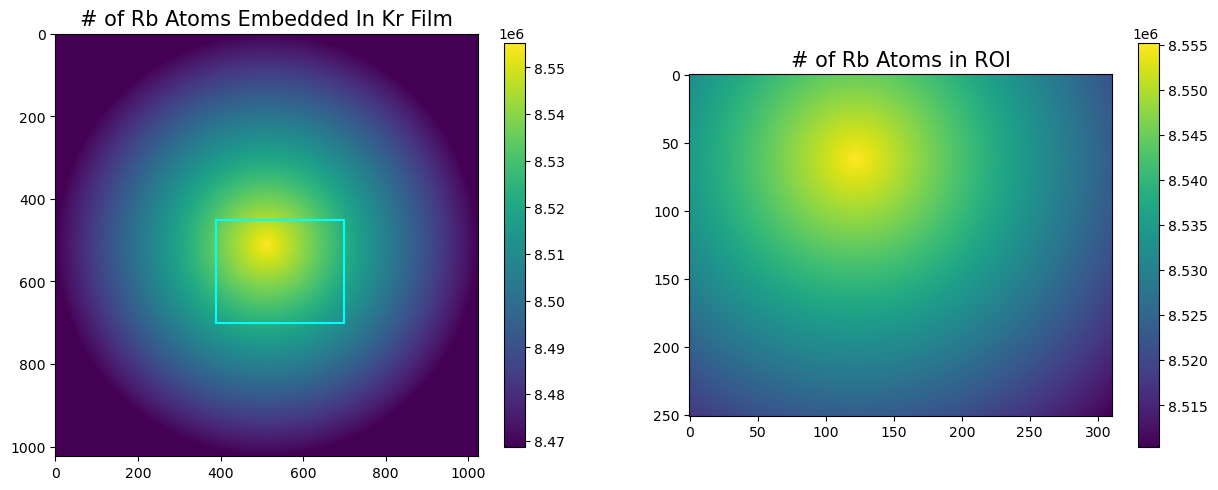

In [202]:
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(atoms)
plt.colorbar(shrink=.35)
plt.plot([roi_x1,roi_x2,roi_x2,roi_x1,roi_x1],[roi_y1,roi_y1,roi_y2,roi_y2,roi_y1], color='cyan') # ROI
plt.clim(atoms[1,500], np.max(atoms))
plt.title("# of Rb Atoms Embedded In Kr Film",fontsize=15)

plt.subplot(1,2,2)
plt.imshow(atoms_roi)
plt.colorbar(shrink=.35)
plt.title("# of Rb Atoms in ROI", fontsize=15)

In [203]:
print(np.sum(atoms))
print(flow_rate*60*60)

6997441822211.728
1080000000000.0


In [204]:
print(np.max(atoms_roi), np.min(atoms_roi))

8555250.868082955 8510357.743511105


In [205]:
#adding to dataframe for histogram purposes
atom_df = []
for y in range(len(atoms_roi)):
    for x in range(len(atoms_roi[0])):
        atom_df.append({
            'x': x,
            'y': y,
            'value': atoms_roi[y][x]})

In [479]:
atom_df = pd.DataFrame(atom_df)

Text(0.5, 0, '# of atoms / cm^2')

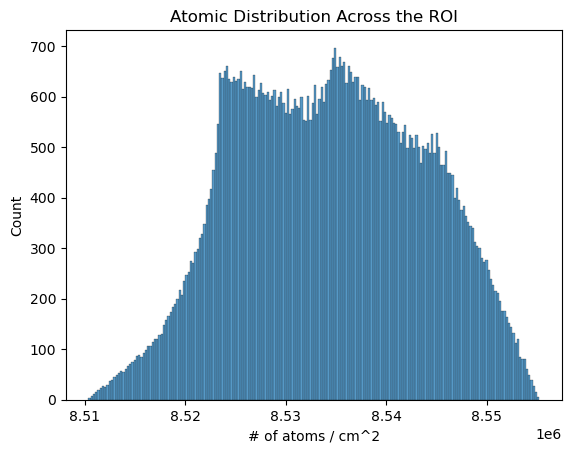

In [512]:
sns.histplot(atom_df['value'], bins=200)
plt.title("Atomic Distribution Across the ROI")
plt.xlabel("# of atoms / cm^2")

In [483]:
#adding to the main table
slopes_table2['atom_dist'] = slopes_table2['sa'] / atom_df['value']

## Final Fluorescence Cross Section Calculations

In [ ]:
#constants 
ctp = 5.2 
transm = 0.907
h = 6.62607015E-34 

In [485]:
#testing with just 
pwr = 1.043/1000  
wl = 730.0E-7  # laser wavelength in meters
vy = 3*10e8/wl # Hz
fcs_array = ( cpp_doped_tot[2][4] * h * vy * ctp ) / ( pwr * atoms * sa * transm)

C:\Users\summe\AppData\Local\Temp\ipykernel_29564\2860151894.py:11: RuntimeWarning: divide by zero encountered in divide
  fcs_array = ( cpp_doped_tot[2][4] * h * vy * ctp ) / ( pwr * atoms * sa * transm)


In [580]:
print(np.median(fcs_array))

7.336646155264955e-15


Text(0.5, 1.0, 'ROI')

<Figure size 640x480 with 0 Axes>

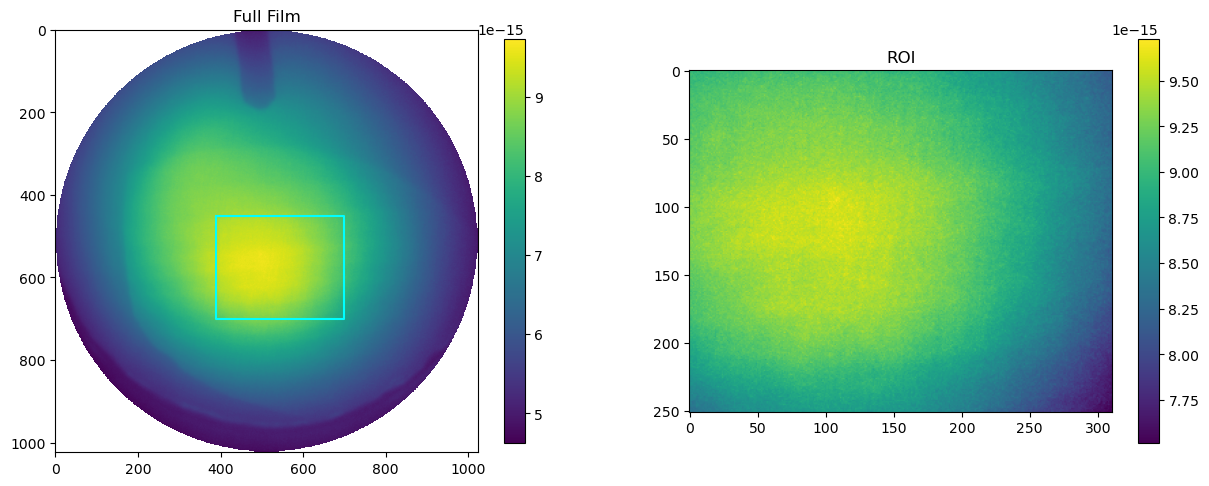

In [548]:
plt.figure(figsize=(15,15))?
plt.subplot(1,2,1)
plt.imshow(fcs_array)#[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1])
plt.plot([roi_x1,roi_x2,roi_x2,roi_x1,roi_x1],[roi_y1,roi_y1,roi_y2,roi_y2,roi_y1], color='cyan') # ROI
plt.colorbar(shrink=.35)
plt.title("Preliminary FCS of Rb at 730nm")

plt.subplot(1,2,2)
fcs_roi = fcs_array[roi_y1:roi_y2+1, roi_x1:roi_x2+1]
plt.imshow(fcs_roi)
plt.colorbar(shrink=.35)
np.median(fcs_roi)
plt.title("ROI")

9.103518364787546e-15

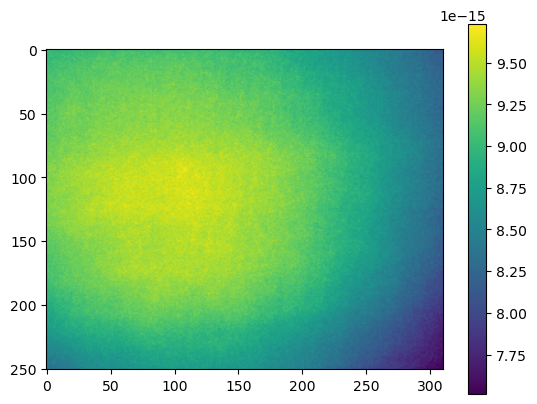

In [528]:
fcs_roi = fcs_array[roi_y1:roi_y2+1, roi_x1:roi_x2+1]
plt.imshow(fcs_roi)
plt.colorbar()
np.median(fcs_roi)

In [530]:
fcs_roi_df = []
for y in range(len(fcs_roi)):          # number of rows
    for x in range(len(fcs_roi[0])):   # number of columns
        fcs_roi_df.append({
            'x': x,
            'y': y,
            'value': fcs_roi[y][x]})

In [532]:
fcs_roi_df = pd.DataFrame(fcs_roi_df)


Text(0.5, 1.0, 'Distribution of cross-sections in the ROI at 730nm')

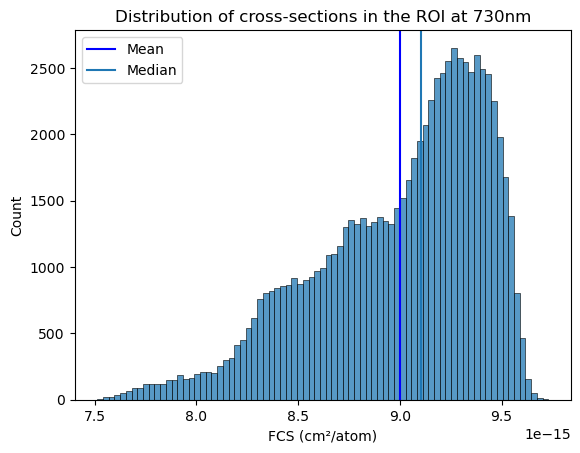

In [536]:
sns.histplot(fcs_roi_df['value'])
plt.xlabel("FCS (cm\u00B2/atom)")
plt.axvline(np.mean(fcs_roi), color='blue', label='Mean')
plt.axvline(np.median(fcs_roi), label='Median')
plt.legend()
plt.title("Distribution of cross-sections in the ROI at 730nm")

In [497]:
test_fcs = np.zeros_like(slopes_test)
for i in range(len(slopes_test)):
    test_fcs[i] = (slopes_test[i] * h * vy * ctp ) / ( atoms * sa *pwr * transm) 

C:\Users\summe\AppData\Local\Temp\ipykernel_29564\4161260280.py:3: RuntimeWarning: invalid value encountered in divide
  test_fcs[i] = (slopes_test[i] * h * vy * ctp ) / ( atoms * sa *pwr * transm)


In [652]:
list(undoped_nm_dict)[2]

'730'

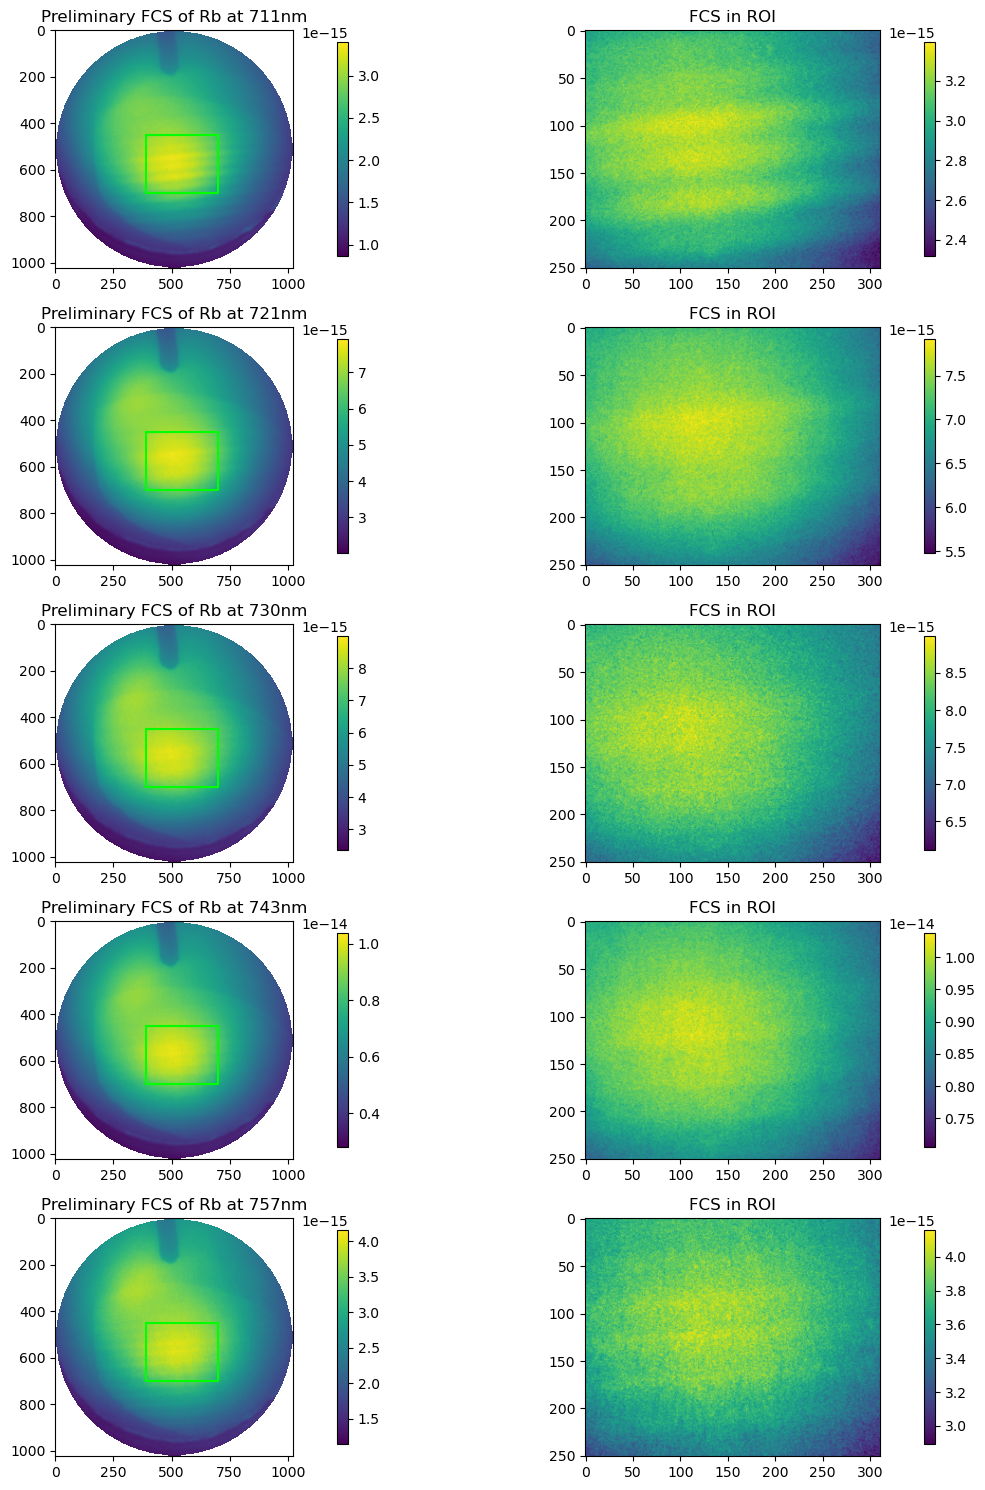

In [725]:
plt.figure(figsize=(15,15))
for i in range(len(test_fcs)):  
    plt.subplot(5,2,1+2*(i))
    plt.imshow(test_fcs[i])
    plt.plot([roi_x1,roi_x2,roi_x2,roi_x1,roi_x1],[roi_y1,roi_y1,roi_y2,roi_y2,roi_y1], color='lime') # ROI
    plt.colorbar(shrink=.9)
    plt.title("Preliminary FCS of Rb at " + list(undoped_nm_dict)[i] + "nm")
    plt.subplot(5,2,2*(i+1))
    plt.imshow(test_fcs[i][roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    plt.colorbar(shrink=.9)
    plt.title("FCS in ROI")
    plt.tight_layout()


In [741]:
for i in range(len(test_fcs)):
    print("The FCS at" , list(undoped_nm_dict)[i] , "nm is" , np.nanmean(test_fcs[i][roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    , "\u00B1" ,  np.nanstd(test_fcs[i][roi_y1:roi_y2+1, roi_x1:roi_x2+1]))


The FCS at 711 nm is 3.0225231385468305e-15 ± 1.9161484659186994e-16
The FCS at 721 nm is 7.102070559356088e-15 ± 4.2161073252159894e-16
The FCS at 730 nm is 8.017072761287928e-15 ± 4.789534220888017e-16
The FCS at 743 nm is 9.256723716617867e-15 ± 5.501723776879832e-16
The FCS at 757 nm is 3.705310827889394e-15 ± 1.9895612465403757e-16
